<a href="https://colab.research.google.com/github/chintu4/LLM-based-Movie-Recommendation/blob/main/data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd
import kagglehub
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
from datasets import load_dataset

data = load_dataset("Pablinho/movies-dataset")

In [13]:
df=pd.DataFrame(data["train"])

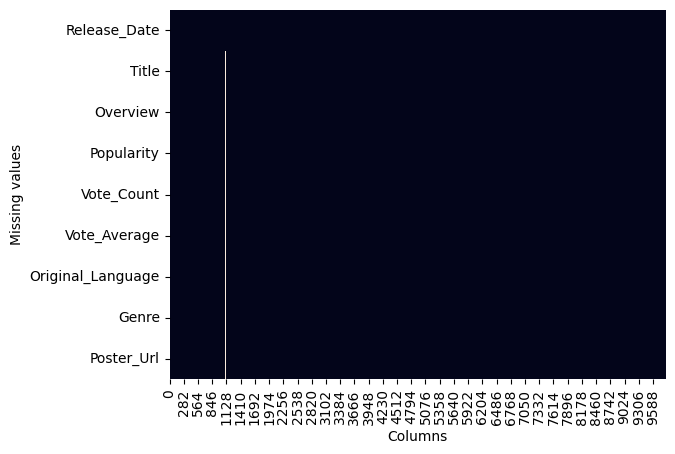

In [14]:
ax = plt.axes()
sns.heatmap(df.isna().transpose(), cbar=False, ax=ax)

plt.xlabel("Columns")
plt.ylabel("Missing values")

plt.show()

In [15]:
import numpy as np
import pandas as pd

df["missing_description"] = np.where(df["Overview"].isna(), 1, 0)
df["Release_Date"] = pd.to_datetime(df["Release_Date"], errors='coerce')
df["age_of_movie"] = 2026 - df["Release_Date"].dt.year

In [16]:
df.value_counts("missing_description")

,count
missing_description,
0,9828
1,9


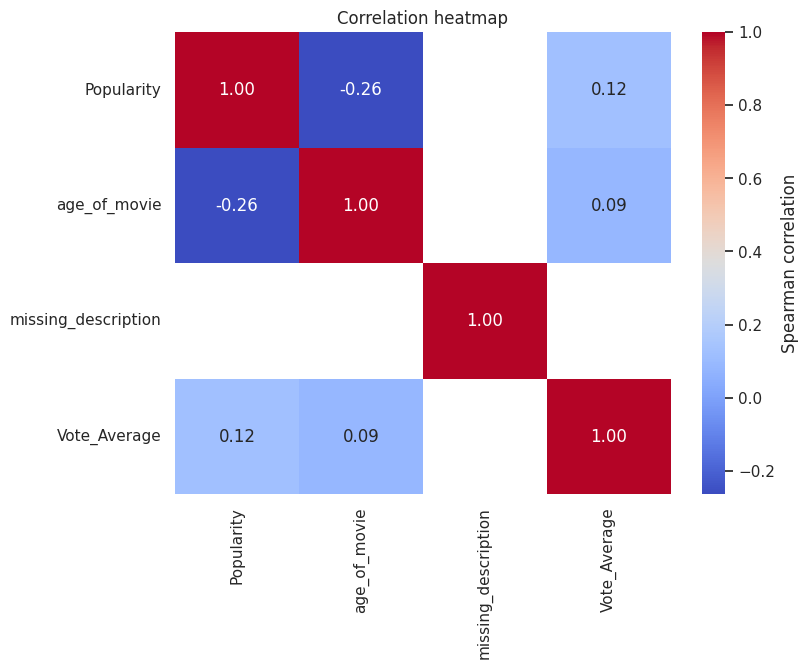

In [17]:
columns_of_interest = ["Popularity", "age_of_movie", "missing_description", "Vote_Average"]

# Force conversion to numeric and drop rows with errors if any hidden strings exist
clean_df = df[columns_of_interest].apply(pd.to_numeric, errors='coerce')
correlation_matrix = clean_df.corr(method="spearman")

sns.set_theme(style="white")
plt.figure(figsize=(8, 6))
heatmap = sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm",
                      cbar_kws={"label": "Spearman correlation"})
heatmap.set_title("Correlation heatmap")
plt.show()

In [18]:
movie_missing = df[~(df["Overview"].isna()) &
      ~(df["Popularity"].isna()) &
      ~(df["Vote_Average"].isna()) &
      ~(df["age_of_movie"].isna())
]

In [19]:
movie_missing

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url,missing_description,age_of_movie
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...,0,5.0
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...,0,4.0
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...,0,4.0
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...,0,5.0
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...,0,5.0
...,...,...,...,...,...,...,...,...,...,...,...
9832,1973-10-15,Badlands,A dramatization of the Starkweather-Fugate kil...,13.357,896,7.6,en,"Drama, Crime",https://image.tmdb.org/t/p/original/z81rBzHNgi...,0,53.0
9833,2020-10-01,Violent Delights,A female vampire falls in love with a man she ...,13.356,8,3.5,es,Horror,https://image.tmdb.org/t/p/original/4b6HY7rud6...,0,6.0
9834,2016-05-06,The Offering,When young and successful reporter Jamie finds...,13.355,94,5.0,en,"Mystery, Thriller, Horror",https://image.tmdb.org/t/p/original/h4uMM1wOhz...,0,10.0
9835,2021-03-31,The United States vs. Billie Holiday,Billie Holiday spent much of her career being ...,13.354,152,6.7,en,"Music, Drama, History",https://image.tmdb.org/t/p/original/vEzkxuE2sJ...,0,5.0


In [20]:
movie_missing["Genre"].value_counts().reset_index().sort_values("count", ascending=False)

,Genre,count
0,Drama,466
1,Comedy,403
2,"Drama, Romance",248
3,Horror,238
4,"Horror, Thriller",199
...,...,...
2327,"Family, Fantasy, Animation",1
2326,"Drama, Romance, Action, Crime",1
2325,"Action, Comedy, Science Fiction, Fantasy",1
2324,"Animation, Comedy, Romance",1


In [21]:
movie_missing

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url,missing_description,age_of_movie
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...,0,5.0
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...,0,4.0
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...,0,4.0
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...,0,5.0
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...,0,5.0
...,...,...,...,...,...,...,...,...,...,...,...
9832,1973-10-15,Badlands,A dramatization of the Starkweather-Fugate kil...,13.357,896,7.6,en,"Drama, Crime",https://image.tmdb.org/t/p/original/z81rBzHNgi...,0,53.0
9833,2020-10-01,Violent Delights,A female vampire falls in love with a man she ...,13.356,8,3.5,es,Horror,https://image.tmdb.org/t/p/original/4b6HY7rud6...,0,6.0
9834,2016-05-06,The Offering,When young and successful reporter Jamie finds...,13.355,94,5.0,en,"Mystery, Thriller, Horror",https://image.tmdb.org/t/p/original/h4uMM1wOhz...,0,10.0
9835,2021-03-31,The United States vs. Billie Holiday,Billie Holiday spent much of her career being ...,13.354,152,6.7,en,"Music, Drama, History",https://image.tmdb.org/t/p/original/vEzkxuE2sJ...,0,5.0


In [22]:
movie_missing = movie_missing.copy()
movie_missing["words_in_description"] = movie_missing["Overview"].str.split().str.len()

In [23]:
movie_missing

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url,missing_description,age_of_movie,words_in_description
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...,0,5.0,45
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...,0,4.0,28
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...,0,4.0,46
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...,0,5.0,89
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...,0,5.0,28
...,...,...,...,...,...,...,...,...,...,...,...,...
9832,1973-10-15,Badlands,A dramatization of the Starkweather-Fugate kil...,13.357,896,7.6,en,"Drama, Crime",https://image.tmdb.org/t/p/original/z81rBzHNgi...,0,53.0,30
9833,2020-10-01,Violent Delights,A female vampire falls in love with a man she ...,13.356,8,3.5,es,Horror,https://image.tmdb.org/t/p/original/4b6HY7rud6...,0,6.0,36
9834,2016-05-06,The Offering,When young and successful reporter Jamie finds...,13.355,94,5.0,en,"Mystery, Thriller, Horror",https://image.tmdb.org/t/p/original/h4uMM1wOhz...,0,10.0,58
9835,2021-03-31,The United States vs. Billie Holiday,Billie Holiday spent much of her career being ...,13.354,152,6.7,en,"Music, Drama, History",https://image.tmdb.org/t/p/original/vEzkxuE2sJ...,0,5.0,40


In [24]:
movie_missing.loc[movie_missing["words_in_description"].between(1, 4), ["Title", "Overview"]]

,Title,Overview
6433,Madu Murni,Plot unknown.


In [25]:
movie_missing.loc[movie_missing["words_in_description"].between(5, 14), "Overview"]

,Overview
87,Terror strikes when a heartbroken woman uses b...
112,"Jennifer Dulos, the wealthy, Connecticut mothe..."
210,The tenth installment in the Fast Saga.
237,Drac tries out some new monster pets to help o...
351,Katniss Everdeen reluctantly becomes the symbo...
...,...
9606,A U.S. Army colonel alerts the president of a ...
9630,A British Special Boat Service commando tracks...
9699,XOXO follows six strangers whose lives collide...
9747,A college prank at an abandoned house accident...


In [26]:
movie_missing.loc[movie_missing["words_in_description"].between(15, 24), "Overview"]

,Overview
8,A revenge mission becomes a fight to save the ...
23,"Plagued by strange memories, Neo's life takes ..."
26,An ex-NYPD officer-turned-sheriff of a small r...
31,Shang-Chi must confront the past he thought he...
34,Two youngsters from rival New York City gangs ...
...,...
9794,Fin and his wife April travel around the world...
9797,An aging thief hopes to retire and live off hi...
9800,A team searching for a long-lost ship in the A...
9818,"The story of a leading political man, suddenly..."


In [27]:
movie_missing.loc[movie_missing["words_in_description"].between(25, 34), "Overview"]

,Overview
1,"In his second year of fighting crime, Batman u..."
4,As a collection of history's worst tyrants and...
12,After going to extremes to cover up an acciden...
13,An ambitious carnival man with a talent for ma...
14,The fearless one-eyed weasel Buck teams up wit...
...,...
9810,"Plagued by a series of apocalyptic visions, a ..."
9813,A soldier returns home to his small town and e...
9821,Against the backdrop of a military dictatorshi...
9832,A dramatization of the Starkweather-Fugate kil...


In [28]:
movie_missing_25_words = movie_missing[movie_missing["words_in_description"] >= 25].copy()

In [29]:
movie_missing_25_words

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url,missing_description,age_of_movie,words_in_description
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...,0,5.0,45
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...,0,4.0,28
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...,0,4.0,46
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...,0,5.0,89
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...,0,5.0,28
...,...,...,...,...,...,...,...,...,...,...,...,...
9832,1973-10-15,Badlands,A dramatization of the Starkweather-Fugate kil...,13.357,896,7.6,en,"Drama, Crime",https://image.tmdb.org/t/p/original/z81rBzHNgi...,0,53.0,30
9833,2020-10-01,Violent Delights,A female vampire falls in love with a man she ...,13.356,8,3.5,es,Horror,https://image.tmdb.org/t/p/original/4b6HY7rud6...,0,6.0,36
9834,2016-05-06,The Offering,When young and successful reporter Jamie finds...,13.355,94,5.0,en,"Mystery, Thriller, Horror",https://image.tmdb.org/t/p/original/h4uMM1wOhz...,0,10.0,58
9835,2021-03-31,The United States vs. Billie Holiday,Billie Holiday spent much of her career being ...,13.354,152,6.7,en,"Music, Drama, History",https://image.tmdb.org/t/p/original/vEzkxuE2sJ...,0,5.0,40


In [30]:
movie_missing_25_words["title_and_subtitle"] = movie_missing_25_words["Title"]

In [31]:
movie_missing_25_words["tagged_description"] = movie_missing_25_words["Overview"]

In [32]:
movie_missing_25_words

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url,missing_description,age_of_movie,words_in_description,title_and_subtitle,tagged_description
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...,0,5.0,45,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...,0,4.0,28,The Batman,"In his second year of fighting crime, Batman u..."
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...,0,4.0,46,No Exit,Stranded at a rest stop in the mountains durin...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...,0,5.0,89,Encanto,"The tale of an extraordinary family, the Madri..."
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...,0,5.0,28,The King's Man,As a collection of history's worst tyrants and...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9832,1973-10-15,Badlands,A dramatization of the Starkweather-Fugate kil...,13.357,896,7.6,en,"Drama, Crime",https://image.tmdb.org/t/p/original/z81rBzHNgi...,0,53.0,30,Badlands,A dramatization of the Starkweather-Fugate kil...
9833,2020-10-01,Violent Delights,A female vampire falls in love with a man she ...,13.356,8,3.5,es,Horror,https://image.tmdb.org/t/p/original/4b6HY7rud6...,0,6.0,36,Violent Delights,A female vampire falls in love with a man she ...
9834,2016-05-06,The Offering,When young and successful reporter Jamie finds...,13.355,94,5.0,en,"Mystery, Thriller, Horror",https://image.tmdb.org/t/p/original/h4uMM1wOhz...,0,10.0,58,The Offering,When young and successful reporter Jamie finds...
9835,2021-03-31,The United States vs. Billie Holiday,Billie Holiday spent much of her career being ...,13.354,152,6.7,en,"Music, Drama, History",https://image.tmdb.org/t/p/original/vEzkxuE2sJ...,0,5.0,40,The United States vs. Billie Holiday,Billie Holiday spent much of her career being ...


In [33]:
cols_to_drop = [c for c in ["missing_description", "age_of_movie", "words_in_description", "age_of_book"] if c in movie_missing_25_words.columns]
movie_missing_25_words.drop(columns=cols_to_drop).to_csv("movies_cleaned.csv", index=False)